# Warp Regression: An Introduction

Many series have a recognisable **shape** whose **timing** drifts — a business cycle that is usually four years but sometimes six, a boom–bust pattern that peaks early one decade and late the next.

Fixed-phase tools (ARIMA, seasonal decomposition) leave nowhere for that wander. Flexible smoothers fit the mistiming as unstructured noise and lose the "same shape, early or late" story.

**Warp regression** sits in between: warp a known-shape cycle through an observation model

$$\hat{y}_i = f\big(\mathrm{warp}(c, p)_i\big)$$

- $f$ maps the warped cycle onto the target (linear, MLP, …).
- $p$ is a low-dimensional path of fractional indices into $c$. Soft-warp interpolates, so gradients flow through $p$.

## Dual loss

Training mixes two likelihoods with weight $\lambda$ (`fit_lambda`):

| Term | Role |
|------|------|
| **error** | Gaussian NLL of residuals $y - \hat{y}$ (scale $\sigma_y$) |
| **terror** | Random-walk likelihood on offsets $p(i)-i$ (scale $\sigma_t$) |

$$\mathrm{loss} = \lambda \cdot \mathrm{error} - (1-\lambda) \cdot \mathrm{terror}$$

Because the path has a likelihood, you can **sample** future paths for forecast bands: a **terror** band (timing only) and a **combined** band (timing + observation noise).

This notebook grades the method on synthetic data with a known true warp; Lynx and Bitcoin follow on real series.


In [1]:
%matplotlib inline

import sys
from pathlib import Path
for _p in (Path.cwd().resolve().parents[1] / "src", Path.cwd().resolve().parent):
    s = str(_p)
    if _p.is_dir() and s not in sys.path:
        sys.path.insert(0, s)

import matplotlib.pyplot as plt
import numpy as np
import torch

from utils import (
    NOTEBOOK_LL_TARGET,
    build_synthetic_dataset,
    cumsum_path_to_stored_path,
    evaluate_model,
    plot_dual_objective_scatter,
    plot_fit_with_residual,
    plot_forecast_bands,
    plot_realisation_spaghetti,
    plot_warp_offset,
    roll_forward_synthetic,
    split_holdout,
)
from warp_regression import (
    DEFAULT_PATH_ANCHOR,
    WarpModel,
    analyze_cycle_lengths,
    build_forecast_bands,
    interval_coverage,
    per_index_rw_sigma,
    plot_cycle_length_distribution,
    predict_forecast_realisations_torch,
    predict_realisations_torch,
    prefit,
    soft_warp_numpy,
    stored_path_offset_numpy,
)

plt.rcParams.update({"figure.figsize": (10, 3.5), "axes.grid": True, "grid.alpha": 0.3})


## Step 1: synthetic data with a known warp

Generate a sine, push it through a hidden random-walk warp, add noise. Hold out the last 100 points so we can check forecasts the same way as on real data.


/Users/ap/Desktop/warp/warp_regression/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


n=300  sr=10  scale=10.0  noise_std=0.2
Train indices 0-180 (n=181)  |  Test indices 181-299 (n=119)


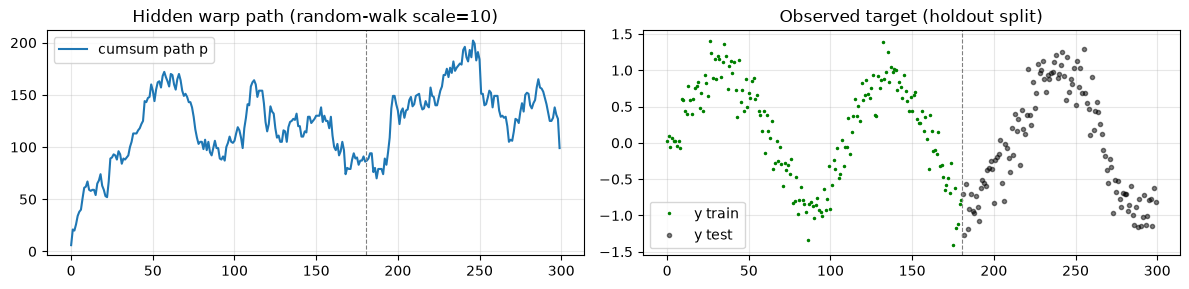

In [2]:
data = build_synthetic_dataset()
print(f"n={data['n']}  sr={data['sr']}  scale={data['scale']}  noise_std={data['noise_std']}")

split = split_holdout(data["n"], n_train=181)
train_idx, test_idx = split["train_idx"], split["test_idx"]
n_train, n_test = split["n_train"], split["n_test"]
print(f"Train indices 0-{n_train - 1} (n={n_train})  |  Test indices {n_train}-{data['n'] - 1} (n={n_test})")

y_train = torch.tensor(data["y"][train_idx], dtype=torch.float32)
sr = data["sr"]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(data["p_true"], label="cumsum path p")
axes[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[0].set_title("Hidden warp path (random-walk scale=10)")
axes[0].legend()
axes[1].plot(train_idx, data["y"][train_idx], "g.", ms=3, label="y train")
axes[1].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.5, label="y test")
axes[1].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
axes[1].set_title("Observed target (holdout split)")
axes[1].legend()
fig.tight_layout()
plt.show()


## Step 2: prefit the cycle on calendar time

Before learning a warp, align a sine to the training series on the calendar (`prefit`). That sine $z$ is what gets warped next:

$$\hat{y} = A \cdot \mathrm{warp}(z, p) + C$$


In [3]:
t_tr = (train_idx + 1).astype(np.float64) / 100.0
t_full = (np.arange(data["n"]) + 1).astype(np.float64) / 100.0
prefit_res = prefit(y_train.numpy(), t_tr, n_sines=1, t_full=t_full)
sine_fit = prefit_res.sine_fit
z_prefit = torch.tensor(prefit_res.covariates["z"], dtype=torch.float32)
print(
    f"prefit: omega={sine_fit['omega']:.3f}  phase={sine_fit['phase']:.3f}  "
    f"corr={sine_fit['presize_corr']:.3f}"
)


prefit: omega=1.000  phase=5.585  corr=0.934


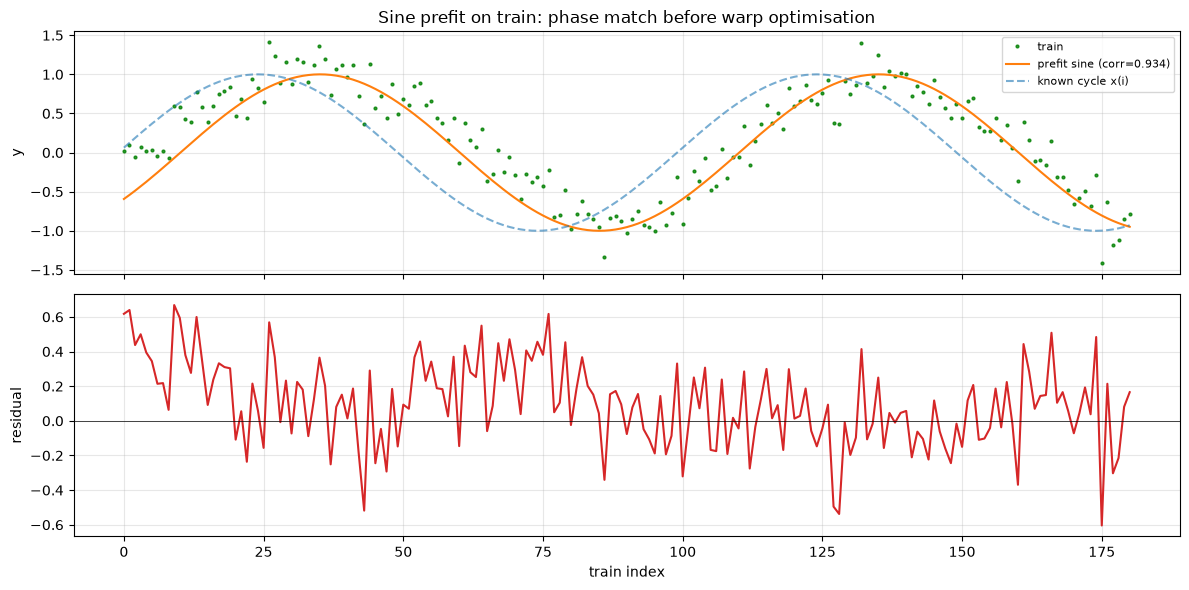

In [4]:

z_pre = sine_fit["z"]
y_np = y_train.numpy()
x_raw = data["x"][:n_train]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_fit_with_residual(
    axes, train_idx, y_np, z_pre,
    extra_lines=[(train_idx, x_raw, {"color": "C0", "ls": "--", "alpha": 0.6, "label": "known cycle x(i)"})],
    fit_label=f"prefit sine (corr={sine_fit['presize_corr']:.3f})",
    xlabel="train index",
    title="Sine prefit on train: phase match before warp optimisation",
)
plt.tight_layout()
plt.show()


## Step 3: joint training

Learn path knots $B$, amplitude $A$, bias $C$, and scales $\sigma_t$, $\sigma_y$ together under the dual loss. The path is **start-pinned** ($p[0]=0$) so the train end can move. The covariate sine is evaluated on an **extended** calendar so expansion can read future cycle values.


In [5]:
from warp_regression.covariates.sine import eval_sine_driver

n_ext = n_train + n_test
t_ext = (np.arange(n_ext) + 1).astype(np.float64) / 100.0
x_ext = eval_sine_driver(
    t_ext, sine_fit["omega"], sine_fit["phase"],
    time_scale=sine_fit.get("time_scale", 1.0),
    t_shift=sine_fit.get("t_shift", 0.0),
)
x_train = torch.tensor(x_ext, dtype=torch.float32)
y_np = y_train.numpy()

model = WarpModel.from_yaml("synthetic.yaml", n=n_train)
model.fit(
    y_np, covariates={"x": x_ext}, sine_fit=sine_fit,
    epochs=5000, lr=0.03, seed=0, fit_lambda=0.5,
)

with torch.no_grad():
    sigma_t = float(model.sigma_t)
    p_fit = model.primary_path.path().numpy()
    y_hat_t, _ = model.predict_torch(
        {"x": x_train}, {}, p=torch.tensor(p_fit), sine_fit=sine_fit
    )
    y_hat_tr = y_hat_t.numpy()
report = evaluate_model(model, y_np, x=x_ext, use_discrete_warp=True, ll_target=NOTEBOOK_LL_TARGET)
print(f"σ_t={sigma_t:.4f}  terminal offset={p_fit[-1]-(n_train-1):.3f}")
print(report)


σ_t=0.1541  terminal offset=1.253
EvalReport(mse=0.04811198201503745, rmse=0.21934443693660766, corr=0.9447101394456587, obj_err=-17.76939582824707, obj_time=0.12027957290410995, err_nll=17.76939582824707, time_ll=-0.12027957290410995, ll_distance=589.6051526738509, discrete_mse=0.04811198353618967)


## Step 4: did the warp recover?

On synthetic data we know the true path. Compare the fitted curve, $p$, and offsets $p(i)-i$ to ground truth.


Path anchor: start-pinned (p[0]=0.00, terminal offset=1.25)
  learned p vs ground-truth stored path corr = 0.996
  prefit sine corr (step 2) = 0.934


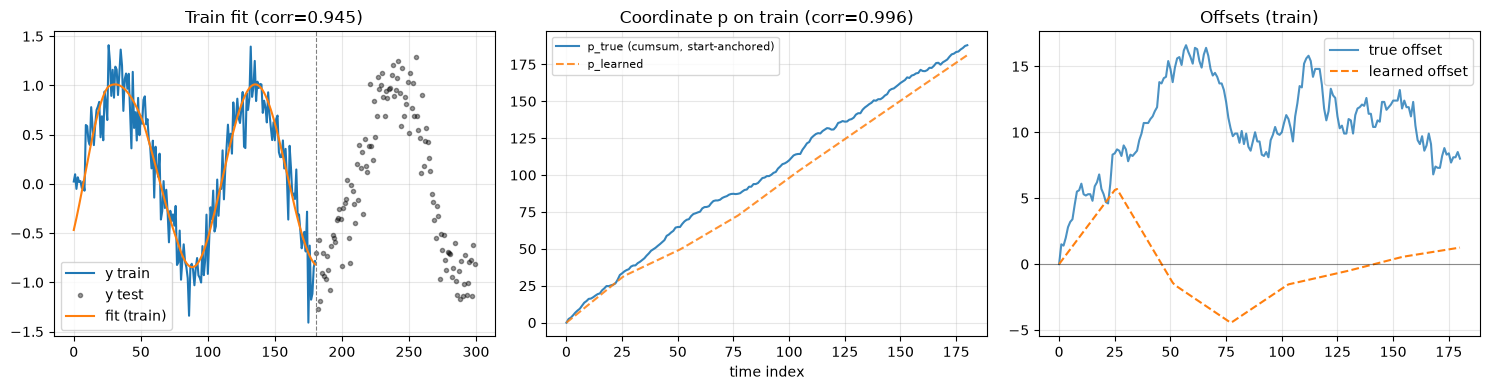

In [6]:
with torch.no_grad():
    p_fit = model.primary_path.path().numpy()
    y_fit_t, _ = model.predict_torch(
        {"x": x_train}, {}, p=torch.tensor(p_fit), sine_fit=sine_fit
    )
    y_fit = y_fit_t.numpy()

p_true_stored = cumsum_path_to_stored_path(
    data["p_true"], n_train, sr, path_anchor=DEFAULT_PATH_ANCHOR
)

off_fit = stored_path_offset_numpy(p_fit)
off_true = stored_path_offset_numpy(p_true_stored)
print(f"Path anchor: start-pinned (p[0]={p_fit[0]:.2f}, terminal offset={off_fit[-1]:.2f})")
print(f"  learned p vs ground-truth stored path corr = {np.corrcoef(p_true_stored, p_fit)[0,1]:.3f}")
print(f"  prefit sine corr (step 2) = {sine_fit['presize_corr']:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(train_idx, y_train.numpy(), label="y train")
ax[0].plot(test_idx, data["y"][test_idx], "ko", ms=3, alpha=0.4, label="y test")
ax[0].plot(y_fit, label="fit (train)")
ax[0].axvline(n_train - 0.5, color="gray", ls="--", lw=0.8)
ax[0].legend()
ax[0].set_title(f"Train fit (corr={report.corr:.3f})")

ax[1].plot(p_true_stored, label="p_true (cumsum, start-anchored)", alpha=0.9)
ax[1].plot(p_fit, linestyle="--", label="p_learned", alpha=0.85)
ax[1].legend(fontsize=8)
ax[1].set_title(f"Coordinate p on train (corr={np.corrcoef(p_true_stored, p_fit)[0,1]:.3f})")
ax[1].set_xlabel("time index")

ax[2].plot(off_true, label="true offset", alpha=0.8)
ax[2].plot(off_fit, linestyle="--", label="learned offset")
ax[2].axhline(0, color="k", linewidth=0.8, alpha=0.4)
ax[2].legend()
ax[2].set_title("Offsets (train)")
plt.tight_layout()
plt.show()


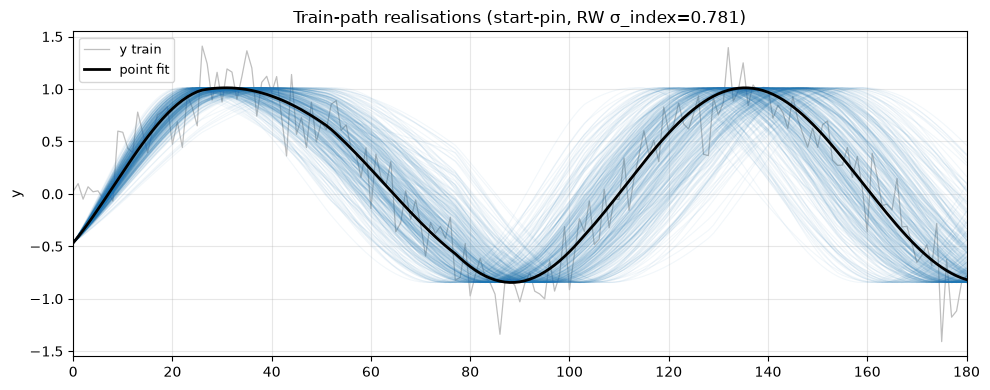

paths shape (400, 181)  std[0]=0.0000  std[180]=0.2664  (expect std[0]≪std[end])


In [7]:
# Sample MAP + start-pinned knot-RW deviations over the train window.
# Uncertainty is ~0 at t=0 and grows toward the train end (around the fit).
h = n_train
n_draws = 400
paths = predict_realisations_torch(model, x=x_ext, n_draws=n_draws, horizon=h)

with torch.no_grad():
    y_fit_t, _ = model.predict_torch({"x": x_train}, {}, sine_fit=sine_fit)
    y_fit = y_fit_t.numpy()

sigma_t = float(model.sigma_t.detach())
sigma_step = per_index_rw_sigma(sigma_t, n_train, model.primary_path.n_knots)

fig, ax = plt.subplots(figsize=(10, 4))
plot_realisation_spaghetti(
    ax, np.arange(h), paths, np.arange(h), y_fit,
    x_obs=train_idx, y_obs=y_np, obs_label="y train",
    point_label="point fit", path_alpha=0.06,
    title=f"Train-path realisations (start-pin, RW σ_index={sigma_step:.3f})",
)
ax.set_xlim(0, h - 1)
fig.tight_layout()
plt.show()

print(
    f"paths shape {paths.shape}  std[0]={paths[:, 0].std():.4f}  "
    f"std[{h-1}]={paths[:, -1].std():.4f}  (expect std[0]≪std[end])"
)


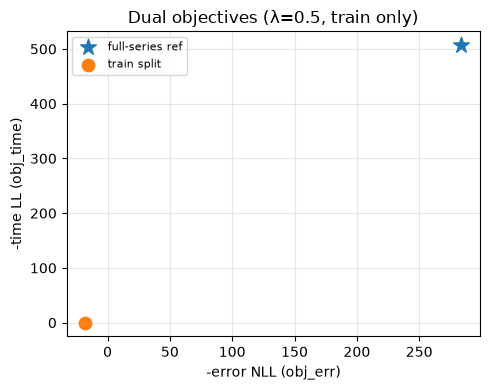

In [8]:
# Where do the two objectives land relative to the full-series reference fit?
fig, ax = plt.subplots(figsize=(5, 4))
plot_dual_objective_scatter(
    ax,
    [
        {"x": NOTEBOOK_LL_TARGET[0], "y": NOTEBOOK_LL_TARGET[1], "label": "full-series ref", "marker": "*", "s": 140},
        {"x": report.obj_err, "y": report.obj_time, "label": "train split", "s": 80},
    ],
    title="Dual objectives (λ=0.5, train only)",
)
plt.tight_layout()
plt.show()


## Step 5: forecast the holdout

Continue the fitted path with a terror-scale random walk. Percentile bands give timing uncertainty (terror) and total predictive uncertainty (terror + $\sigma_y$).


σ_t=0.154  σ_y=0.219  CI 95%: combined coverage=95.0%  terror=68.9%


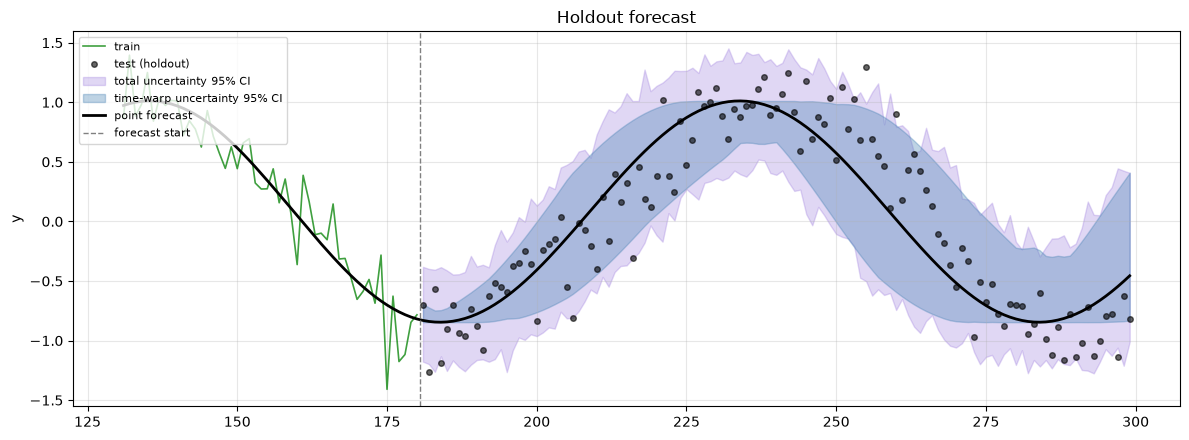

In [9]:
n_future, n_context, n_draws, ci = n_test, 50, 100, 0.95

fc = predict_forecast_realisations_torch(
    model, n_future=n_future, n_draws=n_draws, n_paths_ci=n_draws,
    seed=1, noise_seed=7, sine_fit=sine_fit, ci=ci,
)
y_point, sigma_y, sigma_t = fc["y_point"], fc["sigma_y"], fc["sigma_t"]
y_test = data["y"][test_idx]
bands = build_forecast_bands(fc["preds"][:n_draws], y_point, sigma_y, ci=ci, noise_seed=7)

cov_combined = interval_coverage(y_test, bands["c_q_lo"][test_idx], bands["c_q_hi"][test_idx])
cov_terror = interval_coverage(y_test, bands["t_q_lo"][test_idx], bands["t_q_hi"][test_idx])
print(
    f"σ_t={sigma_t:.3f}  σ_y={sigma_y:.3f}  "
    f"CI {ci:.0%}: combined coverage={cov_combined:.1%}  terror={cov_terror:.1%}"
)

plot_start = max(0, n_train - n_context)
bands_fc = {k: bands[k][n_train:] for k in ("t_q_lo", "t_q_hi", "c_q_lo", "c_q_hi")}
bands_fc["ci"] = ci
fig, ax = plt.subplots(figsize=(12, 4.5))
plot_forecast_bands(
    ax,
    np.arange(plot_start, n_train), data["y"][plot_start:n_train],
    np.arange(n_train, n_train + n_test), bands_fc,
    x_test=test_idx, y_test=y_test,
    point_lines=[(np.arange(plot_start, n_train + n_test), y_point[plot_start:],
                  {"color": "black", "lw": 2, "label": "point forecast"})],
    forecast_start_x=n_train - 0.5,
    title="Holdout forecast",
)
plt.tight_layout(); plt.show()


## Step 6: how long is the next cycle?

Sample future paths and measure peak-to-peak spacing on the warped sine. The dashed line is the nominal period (no warp).


Nominal cycle ≈ 100.0 steps  |  sample median = 99.0 steps  |  σ_t = 0.154

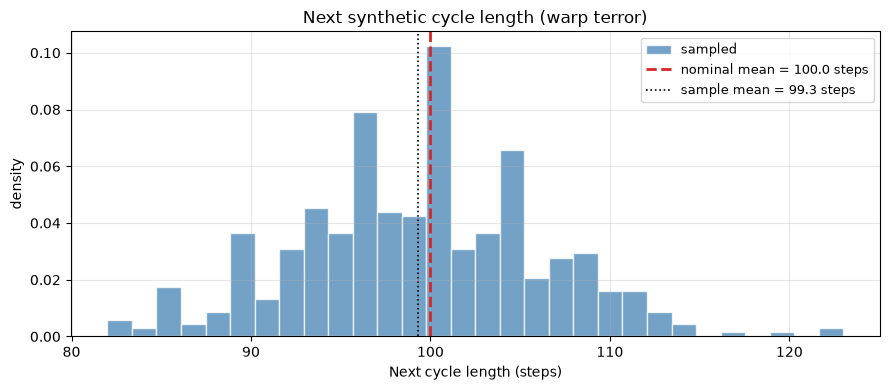

In [10]:
cyc = analyze_cycle_lengths(
    model=model,
    sine_fit=sine_fit,
    n_calendar=n_train,
    unit="steps",
    n_paths=500,
    seed=7,
)
fig, ax = plt.subplots(figsize=(9, 4))
plot_cycle_length_distribution(cyc, ax=ax, title="Next synthetic cycle length (warp terror)")
print(
    f"Nominal cycle ≈ {cyc.mean_cycle_length:.1f} steps  |  "
    f"sample median = {np.median(cyc.lengths):.1f} steps  |  "
    f"σ_t = {cyc.sigma_t:.3f}"
)
fig.tight_layout()
plt.show()


## Step 7: roll-forward coverage

Expanding-window check: at several origins, refit on the past, forecast a fixed horizon, and compare band coverage to the nominal level.


In [11]:
rows = roll_forward_synthetic(data['y'], horizon=100, step=20, t0_first=100, epochs=2000)


roll-forward: origins=100…200 step=20  horizon=100  ci=95%  n_windows=6
   t0     total      warp   cycle_med      σ_t
------------------------------------------------


  100     91.0%     55.0%       106.5    0.148


  120     94.0%     68.0%       103.0    0.144


  140     89.0%     58.0%       109.0    0.145


  160     92.0%     66.0%        99.0    0.155


  180     96.0%     71.0%        99.0    0.154


  200     74.0%     49.0%        96.0    0.156
------------------------------------------------
OVERALL  total 89.3%  warp 61.2%  (nominal 95%)


## Wrapping up

1. Prefit a calendar sine, then warp it under a dual (error + terror) likelihood.
2. On synthetic data the path recovers; holdout bands and cycle-length samples come from path draws.
3. Roll-forward coverage checks that the uncertainty story is not one-window luck.

Next: [`2_Adding_complexity_Lynx_Forecast.ipynb`](2_Adding_complexity_Lynx_Forecast.ipynb) — two cycles, shared warp, nonlinear readout.
